# Tuned 2048 DQN Notebook
## Huấn luyện DQN cho 2048 với wrapper đặc trưng, replay lớn hơn, thăm dò chậm hơn và lựa chọn checkpoint theo probe

Notebook này là phiên bản cải tiến của mô hình DQN cho game 2048, được xây dựng với mục tiêu giải quyết hai vấn đề thường gặp ở các bản chạy trước: mô hình học khá nhanh ở giai đoạn đầu nhưng sớm chững lại, và kết quả đánh giá cuối dễ bị phụ thuộc vào một vài seed đơn lẻ. Vì vậy, toàn bộ pipeline trong bản cải tiến được tổ chức lại theo hướng vừa ổn định hơn khi huấn luyện, vừa đáng tin cậy hơn khi báo cáo kết quả.

Trọng tâm của phiên bản này gồm bốn ý chính. Thứ nhất, trạng thái của bàn chơi không còn được dùng ở dạng vector phẳng đơn giản, mà được mã hoá thành các kênh đặc trưng phù hợp hơn với cấu trúc không gian của 2048. Thứ hai, cơ chế khám phá được kéo dài hơn bằng cách làm chậm quá trình giảm epsilon, giúp agent có thêm thời gian quan sát các kiểu bàn cờ đa dạng trước khi chuyển hẳn sang khai thác. Thứ ba, replay buffer được tăng kích thước để tránh việc kinh nghiệm cũ bị ghi đè quá sớm khi môi trường còn đang sinh ra nhiều trạng thái hữu ích. Cuối cùng, việc lựa chọn mô hình tốt nhất không dựa mù quáng vào checkpoint cuối, mà dựa vào các đợt probe evaluation theo chu kỳ trong quá trình huấn luyện.

Ngoài ra, notebook này còn bổ sung các thành phần quan trọng như prioritized replay, n-step targets, dueling network, Double DQN, cơ chế checkpoint/resume an toàn khi train dài, cùng với bước đánh giá đa seed ở cuối để phản ánh đúng hơn chất lượng chính sách học được.

In [1]:

# Colab / notebook setup
!python -V
!pip -q install --upgrade pip
!pip -q install open-spiel torch matplotlib pandas imageio tqdm


Python 3.12.12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.9 MB/s eta 0:00:00


In [2]:

import copy
import json
import math
import os
import random
import re
import time
import traceback
from collections import Counter, deque, namedtuple
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pyspiel

print("PyTorch version:", torch.__version__)
print("OpenSpiel version:", pyspiel.__version__ if hasattr(pyspiel, "__version__") else "unknown")
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


PyTorch version: 2.10.0+cpu
OpenSpiel version: 1.6.12
CUDA available: False


device(type='cpu')

## 1. Kiểm tra môi trường game và xây dựng các hàm trợ giúp ổn định

Phần đầu tiên của notebook dùng để kiểm tra nhanh cách OpenSpiel biểu diễn game 2048 và để chuẩn bị một nhóm hàm hỗ trợ dùng xuyên suốt toàn bộ quá trình huấn luyện. Với 2048 trong OpenSpiel, trạng thái trò chơi không chỉ gồm các lượt ra quyết định của agent, mà còn có các **chance node** tương ứng với bước môi trường sinh ô mới sau mỗi lần đi. Đây là điểm rất dễ gây lỗi nếu xử lý như một môi trường đơn giản theo kiểu “state → action → next state” thông thường.

Vì lý do đó, các helper trong phần này được viết theo hướng chịu lỗi tốt hơn, có thể tự động rút trích bàn cờ 4x4 từ observation tensor hoặc từ biểu diễn chuỗi của state nếu cần. Đồng thời, notebook cũng cung cấp các hàm để đọc trả thưởng hiện tại, tổng return, legal actions và tự động đi qua các chance node của OpenSpiel trước khi agent quan sát trạng thái tiếp theo. Điều này giúp phần wrapper phía sau hoạt động nhất quán hơn, tránh các lỗi khó dò khi chạy trên Colab, Kaggle hoặc các môi trường notebook có khác biệt nhỏ về phiên bản thư viện.

Nói ngắn gọn, phần này là lớp nền kỹ thuật để đảm bảo rằng từ cell huấn luyện trở đi, agent luôn nhìn thấy đúng trạng thái bàn cờ, nhận được đúng danh sách hành động hợp lệ và không bị gián đoạn bởi các chi tiết nội bộ của OpenSpiel.

In [3]:
game = pyspiel.load_game("2048")
state = game.new_initial_state()

print("Registered game:", game.get_type().short_name)
print("Num distinct actions:", game.num_distinct_actions())
print("Observation tensor shape:", game.observation_tensor_shape())
print("Observation tensor size:", game.observation_tensor_size())
print("Max game length:", game.max_game_length())
print("Initial state:\n", state)

Registered game: 2048
Num distinct actions: 4
Observation tensor shape: [4, 4]
Observation tensor size: 16
Max game length: 8192
Initial state:
     0    0    0    0
    0    0    0    0
    0    0    0    0
    0    0    0    0



In [4]:
def extract_obs_grid(state, player_id=0):
    """Return a 4x4 float32 board from OpenSpiel observation/state."""
    for fn_name, args in [
        ("observation_tensor", (player_id,)),
        ("observation_tensor", tuple()),
        ("information_state_tensor", (player_id,)),
        ("information_state_tensor", tuple()),
    ]:
        fn = getattr(state, fn_name, None)
        if fn is None:
            continue
        try:
            obs = fn(*args)
            obs = np.asarray(obs, dtype=np.float32)
            if obs.shape == (4, 4):
                return obs
            if obs.size == 16:
                return obs.reshape(4, 4)
        except TypeError:
            pass

    numbers = [int(x) for x in re.findall(r"-?\d+", str(state))]
    if len(numbers) >= 16:
        return np.asarray(numbers[:16], dtype=np.float32).reshape(4, 4)

    raise RuntimeError("Could not extract a 4x4 board from the OpenSpiel state.")


def get_state_return(state):
    returns_fn = getattr(state, "returns", None)
    if returns_fn is None:
        return 0.0
    try:
        vals = returns_fn()
    except TypeError:
        vals = returns_fn
    vals = np.asarray(vals, dtype=np.float32).reshape(-1)
    return float(vals[0]) if vals.size else 0.0


def get_state_reward(state):
    rewards_fn = getattr(state, "rewards", None)
    if rewards_fn is None:
        return 0.0
    try:
        vals = rewards_fn()
    except TypeError:
        vals = rewards_fn
    vals = np.asarray(vals, dtype=np.float32).reshape(-1)
    return float(vals[0]) if vals.size else 0.0


def auto_resolve_chance_nodes(state, rng):
    while state.is_chance_node():
        outcomes = state.chance_outcomes()
        actions = np.asarray([a for a, _ in outcomes], dtype=np.int64)
        probs = np.asarray([p for _, p in outcomes], dtype=np.float64)
        probs = probs / probs.sum()
        chosen = int(rng.choice(actions, p=probs))
        state.apply_action(chosen)


def board_to_log2(board):
    board = np.asarray(board, dtype=np.float32)
    out = np.zeros_like(board, dtype=np.int64)
    mask = board > 0
    out[mask] = np.log2(board[mask]).astype(np.int64)
    return out


def monotonicity_score(log_board):
    log_board = np.asarray(log_board, dtype=np.int64)
    total = 0
    for arr in list(log_board) + list(log_board.T):
        arr = np.asarray(arr)
        non_inc = np.sum(arr[:-1] >= arr[1:])
        non_dec = np.sum(arr[:-1] <= arr[1:])
        total += max(int(non_inc), int(non_dec))
    return float(total) / 24.0  # 8 lines * 3 adjacent comparisons


def smoothness_score(log_board):
    log_board = np.asarray(log_board, dtype=np.int64)
    diffs = []
    for r in range(4):
        for c in range(4):
            if log_board[r, c] == 0:
                continue
            if r + 1 < 4 and log_board[r + 1, c] > 0:
                diffs.append(abs(int(log_board[r, c]) - int(log_board[r + 1, c])))
            if c + 1 < 4 and log_board[r, c + 1] > 0:
                diffs.append(abs(int(log_board[r, c]) - int(log_board[r, c + 1])))
    if not diffs:
        return 1.0
    return float(np.clip(1.0 - np.mean(diffs) / 15.0, 0.0, 1.0))


def compute_board_metrics(board, max_log2_channel=15):
    board = np.asarray(board, dtype=np.float32).reshape(4, 4)
    log_board = board_to_log2(board)
    clipped = np.clip(log_board, 0, max_log2_channel)

    empty_count = int(np.sum(board == 0))
    empty_frac = float(empty_count / 16.0)
    max_tile = int(np.max(board))
    max_log = float(np.max(clipped))
    corners = [board[0, 0], board[0, 3], board[3, 0], board[3, 3]]
    corner_flag = float(max_tile > 0 and max_tile in corners)

    return {
        "board": board,
        "log_board": clipped,
        "empty_count": empty_count,
        "empty_frac": empty_frac,
        "max_tile": max_tile,
        "max_log": max_log,
        "corner_flag": corner_flag,
        "monotonicity": monotonicity_score(clipped),
        "smoothness": smoothness_score(clipped),
    }


def encode_board_features(board, max_log2_channel=15):
    """
    Encode board as:
      - 16 one-hot channels for values {empty, 2, 4, ..., 32768}
      - 5 scalar feature maps: empty_count, max_tile_log2, corner_flag, monotonicity, smoothness
    Output shape: [21, 4, 4]
    """
    metrics = compute_board_metrics(board, max_log2_channel=max_log2_channel)
    clipped = metrics["log_board"]

    one_hot = np.eye(max_log2_channel + 1, dtype=np.float32)[clipped]      # [4, 4, 16]
    one_hot = np.transpose(one_hot, (2, 0, 1))                             # [16, 4, 4]

    scalars = [
        metrics["empty_frac"],
        float(metrics["max_log"] / max_log2_channel) if max_log2_channel > 0 else 0.0,
        metrics["corner_flag"],
        metrics["monotonicity"],
        metrics["smoothness"],
    ]
    scalar_maps = np.stack([
        np.full((4, 4), fill_value=v, dtype=np.float32) for v in scalars
    ], axis=0)

    return np.concatenate([one_hot, scalar_maps], axis=0).astype(np.float32)


def make_legal_mask(num_actions, legal_actions_list):
    mask = np.zeros(num_actions, dtype=np.float32)
    if legal_actions_list:
        mask[np.asarray(legal_actions_list, dtype=np.int64)] = 1.0
    return mask

## 2. Xây dựng wrapper đặc trưng cho OpenSpiel 2048

Cell này định nghĩa wrapper chính của môi trường, nơi bàn cờ 2048 được chuyển thành biểu diễn phù hợp hơn cho mạng nơ-ron. Thay vì chỉ dùng trực tiếp vector quan sát thô, bàn chơi được mã hoá thành nhiều kênh đặc trưng để mô hình có thể nhận ra rõ hơn cấu trúc không gian, vị trí của các tile lớn, số ô trống, xu hướng tăng giảm theo hàng/cột và những tín hiệu chiến lược quan trọng khác.

Một điểm quan trọng trong wrapper là phần **reward mode**. Ở đây nhóm hỗ trợ nhiều cách định nghĩa reward để phục vụ thí nghiệm:
- `delta_return`: chỉ dùng thay đổi của score thật trong game;
- `state_rewards`: dùng reward do môi trường trả trực tiếp;
- `shaped`: kết hợp thay đổi score với một số tín hiệu shaping cơ bản;
- `strategic_shaped`: chế độ mạnh hơn, kết hợp một thành phần reward từ score đã được nén theo log với các tín hiệu chiến lược như số ô trống, tiến bộ của max tile, độ đơn điệu của bàn cờ, độ “mượt” giữa các ô lân cận và việc giữ tile lớn ở góc.

Mục tiêu của phần shaping không phải là thay thế hoàn toàn objective gốc của game, mà là bổ sung tín hiệu định hướng trong giai đoạn đầu và giữa của huấn luyện. Trong 2048, nhiều hành động tốt về dài hạn không cho lợi ích rõ ngay ở bước hiện tại, nên nếu chỉ học từ delta score thuần tuý thì agent rất dễ sa vào các chiến lược ngắn hạn. Nói ngắn gọn, phần này vẫn bám theo objective gốc của game, nhưng thêm một số tín hiệu shaping để agent học ổn định hơn ở giai đoạn đầu.

Phần mã sau cell này chịu trách nhiệm reset state, xử lý chance node, tính reward theo chế độ được chọn và biến bàn cờ thành tensor đầu vào cho mạng Q-network. Việc tạo legal action mask được thực hiện ở các hàm trợ giúp và trong vòng lặp huấn luyện/evaluation, thay vì nằm hoàn toàn bên trong wrapper.

In [5]:
class OpenSpiel2048FeatureEnv:
    def __init__(
        self,
        seed=42,
        reward_mode="strategic_shaped",
        empty_cell_bonus=0.5,
        new_max_tile_bonus=6.0,
        monotonicity_bonus=2.0,
        smoothness_bonus=1.0,
        corner_bonus=2.0,
        keep_max_in_corner_bonus=0.5,
        merge_log_reward_scale=4.0,
    ):
        self.game = pyspiel.load_game("2048")
        self.player_id = 0
        self.num_actions = self.game.num_distinct_actions()
        self.rng = np.random.default_rng(seed)
        self.reward_mode = reward_mode
        self.empty_cell_bonus = float(empty_cell_bonus)
        self.new_max_tile_bonus = float(new_max_tile_bonus)
        self.monotonicity_bonus = float(monotonicity_bonus)
        self.smoothness_bonus = float(smoothness_bonus)
        self.corner_bonus = float(corner_bonus)
        self.keep_max_in_corner_bonus = float(keep_max_in_corner_bonus)
        self.merge_log_reward_scale = float(merge_log_reward_scale)
        self.state = None

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = self.game.new_initial_state()
        auto_resolve_chance_nodes(self.state, self.rng)
        board = extract_obs_grid(self.state, self.player_id)
        return encode_board_features(board)

    def legal_actions(self):
        if self.state is None or self.state.is_terminal():
            return []
        return list(self.state.legal_actions())

    def step(self, action):
        if self.state is None:
            raise RuntimeError("Call reset() before step().")
        legal = self.legal_actions()
        if action not in legal:
            raise ValueError(f"Illegal action {action}. Legal actions are {legal}")

        prev_board = extract_obs_grid(self.state, self.player_id)
        prev_metrics = compute_board_metrics(prev_board)
        prev_return = get_state_return(self.state)

        self.state.apply_action(int(action))
        auto_resolve_chance_nodes(self.state, self.rng)

        board = extract_obs_grid(self.state, self.player_id)
        done = self.state.is_terminal()
        metrics = compute_board_metrics(board)

        total_return = get_state_return(self.state)
        delta_return = float(total_return - prev_return)
        raw_state_reward = get_state_reward(self.state)
        delta_empty = int(metrics["empty_count"] - prev_metrics["empty_count"])
        delta_max_log = float(max(0.0, metrics["max_log"] - prev_metrics["max_log"]))
        delta_monotonicity = float(metrics["monotonicity"] - prev_metrics["monotonicity"])
        delta_smoothness = float(metrics["smoothness"] - prev_metrics["smoothness"])
        delta_corner_flag = float(metrics["corner_flag"] - prev_metrics["corner_flag"])
        new_max_tile = float(metrics["max_tile"] > prev_metrics["max_tile"])
        merge_log_reward = math.log2(1.0 + max(delta_return, 0.0))

        if self.reward_mode == "delta_return":
            reward = delta_return
        elif self.reward_mode == "state_rewards":
            reward = raw_state_reward
        elif self.reward_mode == "shaped":
            reward = (
                delta_return
                + self.empty_cell_bonus * delta_empty
                + self.new_max_tile_bonus * new_max_tile
            )
        elif self.reward_mode == "strategic_shaped":
            reward = (
                self.merge_log_reward_scale * merge_log_reward
                + self.empty_cell_bonus * delta_empty
                + self.new_max_tile_bonus * delta_max_log
                + self.monotonicity_bonus * delta_monotonicity
                + self.smoothness_bonus * delta_smoothness
                + self.corner_bonus * delta_corner_flag
                + self.keep_max_in_corner_bonus * metrics["corner_flag"]
            )
        else:
            raise ValueError(f"Unknown reward_mode: {self.reward_mode}")

        info = {
            "board": board.astype(np.int64),
            "state_text": str(self.state),
            "legal_actions": self.legal_actions(),
            "delta_return": delta_return,
            "raw_state_reward": raw_state_reward,
            "delta_empty": delta_empty,
            "delta_max_log": delta_max_log,
            "delta_monotonicity": delta_monotonicity,
            "delta_smoothness": delta_smoothness,
            "delta_corner_flag": delta_corner_flag,
            "new_max_tile_increased": bool(new_max_tile),
            "merge_log_reward": merge_log_reward,
            "max_tile": int(metrics["max_tile"]),
            "corner_flag": bool(metrics["corner_flag"]),
            "monotonicity": float(metrics["monotonicity"]),
            "smoothness": float(metrics["smoothness"]),
            "total_return": total_return,
        }
        return encode_board_features(board), float(reward), done, info

    def render(self):
        if self.state is None:
            print("<empty env>")
        else:
            print(self.state)

In [6]:

# Quick sanity check
sanity_env = OpenSpiel2048FeatureEnv(seed=123, reward_mode="delta_return")
obs = sanity_env.reset(seed=123)
print("Encoded obs shape:", obs.shape)
print("Initial legal actions:", sanity_env.legal_actions())
sanity_env.render()


Encoded obs shape: (21, 4, 4)
Initial legal actions: [0, 1, 2, 3]
    2    0    0    0
    0    0    0    0
    0    0    4    0
    0    0    0    0



## 3. Replay buffer, prioritized replay, n-step returns và kiến trúc Q-network

Phần này triển khai các thành phần cốt lõi của bộ học tăng cường trong phiên bản cải tiến  này. Thay vì chỉ dùng replay buffer đồng nhất như một baseline tối thiểu, notebook bổ sung thêm **prioritized replay** để mô hình ưu tiên học từ những transition có sai số TD lớn hơn. Ý tưởng ở đây là không phải mọi kinh nghiệm đều có giá trị như nhau: các trạng thái khó, các tình huống hiếm hoặc các sai lệch dự đoán lớn thường mang lại nhiều thông tin hơn cho quá trình cập nhật.

Bên cạnh đó, notebook dùng **n-step returns** để giúp tín hiệu phần thưởng lan ngược nhanh hơn. Với 2048, giá trị của một hành động thường chỉ bộc lộ sau nhiều bước tiếp theo, nên cập nhật một bước rất dễ khiến học chậm và khó nắm bắt chiến lược dài hạn. N-step targets giúp mô hình nhìn xa hơn một chút mà vẫn giữ được tính khả thi trong huấn luyện.

Về kiến trúc mạng, phiên bản này sử dụng Q-network dạng tích chập với tuỳ chọn **dueling heads**. Kiểu kiến trúc này phù hợp hơn với 2048 vì bàn cờ là một cấu trúc 2 chiều rõ ràng, nơi vị trí tương đối giữa các tile có ý nghĩa quan trọng. Dueling network giúp tách phần giá trị của trạng thái và phần lợi thế của từng hành động, nhờ đó mô hình có thể ước lượng ổn định hơn trong những trạng thái mà nhiều hành động có chất lượng gần nhau.

Khi kết hợp prioritized replay, n-step returns, Double DQN và Huber loss, phần này tạo nên lõi học của mô hình: vừa đủ mạnh để cải thiện kết quả, nhưng vẫn giữ được độ rõ ràng và khả năng giải thích của pipeline.

In [7]:
Transition = namedtuple(
    "Transition",
    ["obs", "action", "reward", "next_obs", "done", "legal_mask", "next_legal_mask", "discount"],
)


class UniformReplayBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.buffer = deque(maxlen=self.capacity)

    def __len__(self):
        return len(self.buffer)

    def add(self, *args, priority=None):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size, beta=None):
        idx = np.random.choice(len(self.buffer), size=batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        weights = np.ones(batch_size, dtype=np.float32)
        return Transition(*zip(*batch)), idx, weights

    def update_priorities(self, indices, priorities):
        return None


class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6, priority_eps=1e-6):
        self.capacity = int(capacity)
        self.alpha = float(alpha)
        self.priority_eps = float(priority_eps)
        self.buffer = []
        self.priorities = np.zeros(self.capacity, dtype=np.float32)
        self.pos = 0

    def __len__(self):
        return len(self.buffer)

    def add(self, *args, priority=None):
        transition = Transition(*args)
        max_prio = float(self.priorities[:len(self.buffer)].max()) if self.buffer else 1.0
        prio = max(float(priority) if priority is not None else max_prio, self.priority_eps)

        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.pos] = transition

        self.priorities[self.pos] = prio
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        n = len(self.buffer)
        probs = self.priorities[:n] ** self.alpha
        probs_sum = probs.sum()
        if probs_sum <= 0:
            probs = np.full(n, 1.0 / n, dtype=np.float32)
        else:
            probs = probs / probs_sum

        replace = n < batch_size
        indices = np.random.choice(n, size=batch_size, replace=replace, p=probs)
        batch = [self.buffer[i] for i in indices]

        weights = (n * probs[indices]) ** (-float(beta))
        weights = weights / max(weights.max(), 1e-8)
        weights = weights.astype(np.float32)

        return Transition(*zip(*batch)), indices, weights

    def update_priorities(self, indices, priorities):
        for idx, prio in zip(indices, priorities):
            self.priorities[int(idx)] = max(float(abs(prio)), self.priority_eps)


class NStepTransitionAccumulator:
    def __init__(self, n_step, gamma):
        self.n_step = int(max(1, n_step))
        self.gamma = float(gamma)
        self.buffer = deque()

    def reset(self):
        self.buffer.clear()

    def _build_one(self):
        reward = 0.0
        discount = 1.0
        done = False
        next_obs = None
        next_legal_mask = None

        for i, item in enumerate(self.buffer):
            reward += discount * float(item["reward"])
            discount *= self.gamma
            next_obs = item["next_obs"]
            next_legal_mask = item["next_legal_mask"]
            done = bool(item["done"])
            if done or (i + 1) >= self.n_step:
                break

        first = self.buffer[0]
        self.buffer.popleft()

        return Transition(
            first["obs"],
            int(first["action"]),
            float(reward),
            next_obs,
            bool(done),
            first["legal_mask"],
            next_legal_mask,
            float(discount),
        )

    def add(self, obs, action, reward, next_obs, done, legal_mask, next_legal_mask):
        self.buffer.append({
            "obs": obs,
            "action": action,
            "reward": reward,
            "next_obs": next_obs,
            "done": done,
            "legal_mask": legal_mask,
            "next_legal_mask": next_legal_mask,
        })

        ready = []
        if len(self.buffer) >= self.n_step:
            ready.append(self._build_one())

        if done:
            while self.buffer:
                ready.append(self._build_one())

        return ready


class DuelingConvQNet(nn.Module):
    def __init__(self, in_channels, num_actions, dueling=True):
        super().__init__()
        self.dueling = dueling
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.trunk = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
        )
        if dueling:
            self.value_stream = nn.Sequential(
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, 1),
            )
            self.adv_stream = nn.Sequential(
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, num_actions),
            )
        else:
            self.head = nn.Sequential(
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, num_actions),
            )

    def forward(self, x):
        z = self.features(x)
        z = self.trunk(z)
        if self.dueling:
            value = self.value_stream(z)
            adv = self.adv_stream(z)
            return value + adv - adv.mean(dim=1, keepdim=True)
        return self.head(z)

## 4. Cấu hình trung tâm cho toàn bộ thí nghiệm

Tất cả siêu tham số quan trọng của notebook được gom lại trong một dictionary cấu hình duy nhất để tiện theo dõi, so sánh và tái lập. Cách tổ chức này giúp việc chạy thử nghiệm có kiểm soát hơn: thay vì sửa rải rác ở nhiều cell, người dùng chỉ cần thay đổi trực tiếp trong khối config và toàn bộ pipeline sẽ sử dụng cùng một nguồn tham số nhất quán.

Nhóm tham số trong phần này gồm: số episode huấn luyện, kích thước replay buffer, batch size, hệ số discount, learning rate, tần suất đồng bộ target network, thời điểm bắt đầu học, số bước tối đa mỗi episode và ngưỡng cắt gradient. Ngoài ra còn có nhóm tham số riêng cho exploration như `EPS_START`, `EPS_END`, `EPS_DECAY_STEPS`; nhóm tuỳ chọn thuật toán như Double DQN, dueling, n-step; nhóm tham số cho prioritized replay; nhóm tham số cho reward shaping; và nhóm tham số phục vụ probe evaluation, checkpointing, resume và đánh giá cuối.

In [8]:
CONFIG = {
    # Repro / training
    "TRAIN_SEED": 7,
    "NUM_EPISODES": 6000,          # start here; raise to 8000-10000 only if probe still improves
    "BUFFER_SIZE": 200_000,        # larger replay to reduce early overwriting once exploration broadens
    "BATCH_SIZE": 128,
    "GAMMA": 0.99,
    "LR": 2.5e-4,
    "TARGET_SYNC_EVERY": 1000,
    "LEARN_START": 10_000,
    "LEARN_EVERY": 4,
    "MAX_STEPS_PER_EPISODE": 5000,
    "GRAD_CLIP": 10.0,

    # Exploration
    "EPS_START": 1.0,
    "EPS_END": 0.01,
    "EPS_DECAY_STEPS": 400_000,    # much slower decay to avoid plateauing too early

    # Architecture / algorithm
    "USE_DOUBLE_DQN": True,
    "USE_DUELING": True,
    "N_STEP": 3,

    # Replay
    "USE_PRIORITIZED_REPLAY": True,
    "PER_ALPHA": 0.6,
    "PER_BETA_START": 0.4,
    "PER_BETA_END": 1.0,
    "PER_BETA_ANNEAL_STEPS": 600_000,
    "PRIORITY_EPS": 1e-6,

    # Reward mode
    "REWARD_MODE": "strategic_shaped",   # choose: delta_return, state_rewards, shaped, strategic_shaped
    "EMPTY_CELL_BONUS": 0.5,
    "NEW_MAX_TILE_BONUS": 6.0,
    "MONOTONICITY_BONUS": 2.0,
    "SMOOTHNESS_BONUS": 1.0,
    "CORNER_BONUS": 2.0,
    "KEEP_MAX_IN_CORNER_BONUS": 0.5,
    "MERGE_LOG_REWARD_SCALE": 4.0,

    # Probe evaluation during training
    "PROBE_EVERY_EPISODES": 50,
    "PROBE_SEEDS": [1001, 1002, 1003, 1004, 1005],
    "PRINT_PROBE_SUMMARY": True,
    "SAVE_BEST_PROBE_CHECKPOINT": True,
    "USE_BEST_PROBE_FOR_FINAL_EVAL": True,
    "MIN_PROBE_DELTA": 25.0,          # minimum mean-greedy-return improvement to count as new best
    "EARLY_STOP_ON_PROBE_PLATEAU": False,
    "EARLY_STOP_PATIENCE_PROBES": 20, # with PROBE_EVERY=50 -> 1000 episodes without improvement
    "EARLY_STOP_MIN_EPISODES": 2500,

    # Final evaluation
    "EVAL_SEEDS": list(range(2001, 2051)),
    "PRINT_EACH_EVAL_SEED": True,

    # Save / resume / hang protection
    "SAVE_PATH": "dqn_2048_v4_best_probe.pt",
    "CHECKPOINT_DIR": "./ckpt_2048_v4_plateau_fix",
    "CHECKPOINT_EVERY_EPISODES": 50,
    "HEARTBEAT_EVERY_EPISODES": 10,
    "PRINT_HEARTBEAT": True,
    "EPISODE_WARN_SECONDS": 60.0,
    "EPISODE_ABORT_SECONDS": 180.0,
    "AUTO_RESUME": True,
    "RESUME_PATH": None,                # None -> use latest checkpoint in CHECKPOINT_DIR if AUTO_RESUME=True
    "SAVE_REPLAY_IN_CHECKPOINT": False, # keep lightweight by default
    "STATUS_JSON": "train_status_2048_v4.json",
}

CONFIG

{'TRAIN_SEED': 7,
 'NUM_EPISODES': 6000,
 'BUFFER_SIZE': 200000,
 'BATCH_SIZE': 128,
 'GAMMA': 0.99,
 'LR': 0.00025,
 'TARGET_SYNC_EVERY': 1000,
 'LEARN_START': 10000,
 'LEARN_EVERY': 4,
 'MAX_STEPS_PER_EPISODE': 5000,
 'GRAD_CLIP': 10.0,
 'EPS_START': 1.0,
 'EPS_END': 0.01,
 'EPS_DECAY_STEPS': 400000,
 'USE_DOUBLE_DQN': True,
 'USE_DUELING': True,
 'N_STEP': 3,
 'USE_PRIORITIZED_REPLAY': True,
 'PER_ALPHA': 0.6,
 'PER_BETA_START': 0.4,
 'PER_BETA_END': 1.0,
 'PER_BETA_ANNEAL_STEPS': 600000,
 'PRIORITY_EPS': 1e-06,
 'REWARD_MODE': 'strategic_shaped',
 'EMPTY_CELL_BONUS': 0.5,
 'NEW_MAX_TILE_BONUS': 6.0,
 'MONOTONICITY_BONUS': 2.0,
 'SMOOTHNESS_BONUS': 1.0,
 'CORNER_BONUS': 2.0,
 'KEEP_MAX_IN_CORNER_BONUS': 0.5,
 'MERGE_LOG_REWARD_SCALE': 4.0,
 'PROBE_EVERY_EPISODES': 50,
 'PROBE_SEEDS': [1001, 1002, 1003, 1004, 1005],
 'PRINT_PROBE_SUMMARY': True,
 'SAVE_BEST_PROBE_CHECKPOINT': True,
 'USE_BEST_PROBE_FOR_FINAL_EVAL': True,
 'MIN_PROBE_DELTA': 25.0,
 'EARLY_STOP_ON_PROBE_PLATEAU': False

## 4b. Những thay đổi cốt lõi trong phiên bản cải tiến

Phiên bản này được xây dựng sau khi phân tích kỹ các run trước đó và nhận thấy một mô thức lặp lại: mô hình thường tiến bộ khá nhanh ở giai đoạn đầu, sau đó đạt đỉnh sớm và dao động hoặc đi ngang trong phần còn lại của quá trình train. Vì vậy, các thay đổi trong bản này được chọn có chủ đích để xử lý đúng hiện tượng đó.

Thay đổi đầu tiên là **giảm epsilon chậm hơn**. Khi exploration kết thúc quá sớm, agent dễ mắc kẹt ở một chính sách “đủ ổn” nhưng chưa tốt. Việc kéo dài giai đoạn thăm dò giúp mô hình tiếp tục quan sát các kiểu bàn cờ đa dạng hơn và tránh chốt chiến lược quá sớm.

Thay đổi thứ hai là **mở rộng replay buffer**. Nếu replay quá nhỏ, các kinh nghiệm cũ sẽ bị thay thế nhanh trong khi agent còn đang học những khái niệm cơ bản. Replay lớn hơn giúp phân phối mẫu ổn định hơn và giảm hiện tượng học lệch về các trạng thái mới xuất hiện gần đây.

Thay đổi thứ ba là **probe evaluation theo chu kỳ ngắn hơn**. Thay vì chỉ nhìn checkpoint cuối, notebook đánh giá định kỳ sau mỗi một số episode cố định để theo dõi quá trình học một cách chi tiết hơn.

Thay đổi thứ tư là **lưu checkpoint tốt nhất theo probe**. Với các bài toán ngẫu nhiên như 2048, checkpoint cuối chưa chắc là checkpoint tốt nhất. Việc lưu lại mô hình có hiệu năng probe cao nhất giúp bước đánh giá cuối ít bị phụ thuộc vào việc huấn luyện kéo dài thêm nhưng không cải thiện thực sự.

Nhìn chung, phiên bản cải tiến không phải là một bản viết lại toàn bộ mô hình, mà là một bản tinh chỉnh có hệ thống: thay những thứ tác động trực tiếp đến độ ổn định, chất lượng khám phá và độ tin cậy của quá trình lựa chọn mô hình.

## 4c. Checkpoint an toàn và cơ chế resume khi train dài

Huấn luyện DQN cho 2048 với nhiều episode, nhiều seed probe và replay buffer lớn có thể kéo dài khá lâu, đặc biệt khi chạy trên môi trường notebook (Kaggle). Vì vậy, cell này được thêm vào để giảm rủi ro mất tiến độ khi runtime bị ngắt, người dùng dừng giữa chừng hoặc phiên làm việc bị hết thời gian.

Phần này xử lý việc tạo thư mục checkpoint, đặt tên file nhất quán, lưu trạng thái mô hình, target network, optimizer, log huấn luyện, metadata cần thiết để resume và trạng thái của các bộ sinh số ngẫu nhiên. Ngoài checkpoint theo episode, notebook còn duy trì thông tin về checkpoint mới nhất và checkpoint tốt nhất theo probe, giúp việc resume hoặc đánh giá lại trở nên thuận tiện hơn.

In [9]:

def ensure_dir(path_like):
    path = Path(path_like)
    path.mkdir(parents=True, exist_ok=True)
    return path


def checkpoint_dir(cfg):
    return ensure_dir(cfg["CHECKPOINT_DIR"])


def checkpoint_path(cfg, train_seed, episode, tag="episode"):
    ckpt_dir = checkpoint_dir(cfg)
    return ckpt_dir / f"seed_{int(train_seed)}_{tag}_ep_{int(episode):05d}.pt"


def latest_checkpoint_path(cfg, train_seed=None):
    ckpt_dir = checkpoint_dir(cfg)
    if train_seed is None:
        matches = sorted(ckpt_dir.glob("seed_*_latest.pt"))
    else:
        matches = sorted(ckpt_dir.glob(f"seed_{int(train_seed)}_latest.pt"))
    return matches[-1] if matches else None


def _rng_state_payload():
    payload = {
        "python_random_state": random.getstate(),
        "numpy_random_state": np.random.get_state(),
        "torch_random_state": torch.get_rng_state(),
        "cuda_random_state_all": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }
    return payload


def _restore_rng_state(payload):
    if not payload:
        return
    try:
        if payload.get("python_random_state") is not None:
            random.setstate(payload["python_random_state"])
        if payload.get("numpy_random_state") is not None:
            np.random.set_state(payload["numpy_random_state"])
        if payload.get("torch_random_state") is not None:
            torch.set_rng_state(payload["torch_random_state"])
        if torch.cuda.is_available() and payload.get("cuda_random_state_all") is not None:
            torch.cuda.set_rng_state_all(payload["cuda_random_state_all"])
    except Exception as exc:
        print(f"[warn] Could not fully restore RNG state: {exc}")


def write_status_json(cfg, payload):
    status_path = Path(cfg["STATUS_JSON"])
    status = {
        "saved_at": payload.get("saved_at"),
        "train_seed": payload.get("train_seed"),
        "episode_completed": payload.get("episode_completed"),
        "global_step": payload.get("global_step"),
        "checkpoint_path": str(payload.get("checkpoint_path", "")),
        "stop_reason": payload.get("stop_reason", "running"),
    }
    status_path.write_text(json.dumps(status, indent=2))
    return status_path


def make_training_checkpoint(
    cfg,
    train_seed,
    episode_completed,
    global_step,
    q_net,
    target_net,
    optimizer,
    replay,
    episode_train_rewards,
    episode_true_scores,
    episode_lengths,
    episode_max_tiles,
    loss_history,
    probe_records,
    in_channels,
    num_actions,
    stop_reason="running",
    include_replay=None,
):
    if include_replay is None:
        include_replay = bool(cfg.get("SAVE_REPLAY_IN_CHECKPOINT", False))
    payload = {
        "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "train_seed": int(train_seed),
        "episode_completed": int(episode_completed),
        "global_step": int(global_step),
        "config": copy.deepcopy(cfg),
        "in_channels": int(in_channels),
        "num_actions": int(num_actions),
        "model_state_dict": q_net.state_dict(),
        "target_state_dict": target_net.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "episode_returns": list(episode_train_rewards),
        "episode_true_scores": list(episode_true_scores),
        "episode_lengths": list(episode_lengths),
        "episode_max_tiles": list(episode_max_tiles),
        "loss_history": list(loss_history),
        "probe_records": list(probe_records),
        "stop_reason": stop_reason,
        "rng_state": _rng_state_payload(),
    }
    if include_replay:
        payload["replay"] = replay
        payload["replay_saved"] = True
    else:
        payload["replay_saved"] = False
    return payload


def save_training_checkpoint(payload, cfg, train_seed, episode_completed, tag="episode"):
    path = checkpoint_path(cfg, train_seed, episode_completed, tag=tag)
    payload = dict(payload)
    payload["checkpoint_path"] = str(path)
    torch.save(payload, path)
    latest_path = checkpoint_dir(cfg) / f"seed_{int(train_seed)}_latest.pt"
    torch.save(payload, latest_path)
    write_status_json(cfg, payload)
    return path, latest_path


def load_training_checkpoint(path, map_location=DEVICE):
    path = Path(path)
    payload = torch.load(path, map_location=map_location, weights_only=False)
    return payload


## 5. Chọn hành động, cập nhật Double DQN và các hàm đánh giá

Sau khi đã có môi trường, wrapper và replay buffer, phần này xây dựng logic ra quyết định và cập nhật tham số của mô hình. Một hàm quan trọng ở đây là `masked_greedy_action`, nơi Q-values được dùng để chọn hành động nhưng vẫn luôn tôn trọng legal action mask của môi trường. Điều này đặc biệt cần thiết trong 2048 vì ở nhiều trạng thái chỉ có một vài hướng đi là hợp lệ.

Về cập nhật, notebook dùng **Double DQN** để giảm sai lệch overestimation vốn thường xuất hiện trong DQN chuẩn. Mạng online được dùng để chọn hành động tốt nhất ở trạng thái kế tiếp, còn mạng target được dùng để đánh giá hành động đó. Khi kết hợp với Huber loss, clipped gradients và importance-sampling weights từ prioritized replay, phép cập nhật trở nên ổn định hơn đáng kể.

Ngoài phần học, cell này còn chứa các hàm phục vụ evaluation. Một điểm được nhấn mạnh trong notebook là cần tách rõ giữa **reward dùng để train** và **true game score dùng để báo cáo**. Dù train có dùng reward shaping, quá trình đánh giá cuối vẫn in ra score thật của game theo từng seed, sau đó mới tổng hợp mean, std, median, max tile distribution và tỷ lệ hành động bất hợp lệ bị tránh theo tiêu chí raw argmax trước masking. Đây là cơ sở để kết quả cuối có giá trị phân tích, chứ không chỉ đẹp về mặt con số.

In [10]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def epsilon_by_step(step, cfg):
    frac = min(1.0, step / cfg["EPS_DECAY_STEPS"])
    return cfg["EPS_START"] + frac * (cfg["EPS_END"] - cfg["EPS_START"])


def per_beta_by_step(step, cfg):
    frac = min(1.0, step / cfg["PER_BETA_ANNEAL_STEPS"])
    return cfg["PER_BETA_START"] + frac * (cfg["PER_BETA_END"] - cfg["PER_BETA_START"])


def masked_greedy_action(q_net, obs, legal_actions, num_actions, epsilon=0.0, device=DEVICE, return_debug=False):
    if len(legal_actions) == 0:
        raise RuntimeError("No legal actions available.")

    with torch.no_grad():
        x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        q_values = q_net(x).squeeze(0).detach().cpu().numpy()

    raw_argmax = int(np.argmax(q_values))
    raw_argmax_is_legal = raw_argmax in set(legal_actions)

    if random.random() < epsilon:
        action = int(random.choice(legal_actions))
    else:
        masked_q = q_values.copy()
        illegal = np.ones(num_actions, dtype=bool)
        illegal[np.asarray(legal_actions, dtype=np.int64)] = False
        masked_q[illegal] = -1e9
        action = int(np.argmax(masked_q))

    if return_debug:
        return action, {
            "raw_q": q_values,
            "raw_argmax": raw_argmax,
            "raw_argmax_is_legal": raw_argmax_is_legal,
        }
    return action


def dqn_update(batch, weights, q_net, target_net, optimizer, cfg):
    obs = torch.tensor(np.asarray(batch.obs), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(batch.action, dtype=torch.int64, device=DEVICE).unsqueeze(1)
    rewards = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE)
    next_obs = torch.tensor(np.asarray(batch.next_obs), dtype=torch.float32, device=DEVICE)
    dones = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE)
    discounts = torch.tensor(batch.discount, dtype=torch.float32, device=DEVICE)
    next_legal_mask = torch.tensor(np.asarray(batch.next_legal_mask), dtype=torch.bool, device=DEVICE)
    weights_t = torch.tensor(np.asarray(weights), dtype=torch.float32, device=DEVICE)

    q_values = q_net(obs)
    q_sa = q_values.gather(1, actions).squeeze(1)

    with torch.no_grad():
        no_legal_next = ~next_legal_mask.any(dim=1)

        if cfg["USE_DOUBLE_DQN"]:
            online_next_q = q_net(next_obs).masked_fill(~next_legal_mask, -1e9)
            next_actions = online_next_q.argmax(dim=1, keepdim=True)
            target_next_q = target_net(next_obs).gather(1, next_actions).squeeze(1)
            target_next_q = target_next_q.masked_fill(no_legal_next, 0.0)
        else:
            target_next_q = target_net(next_obs).masked_fill(~next_legal_mask, -1e9)
            target_next_q = target_next_q.max(dim=1).values
            target_next_q = target_next_q.masked_fill(no_legal_next, 0.0)

        target = rewards + (1.0 - dones) * discounts * target_next_q

    td_error = target - q_sa
    per_item_loss = F.smooth_l1_loss(q_sa, target, reduction="none")
    loss = (weights_t * per_item_loss).mean()

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), cfg["GRAD_CLIP"])
    optimizer.step()

    return float(loss.item()), np.abs(td_error.detach().cpu().numpy()) + cfg["PRIORITY_EPS"]


def evaluate_greedy_policy(
    q_net,
    seeds,
    cfg,
    reward_mode=None,
    render_rollout_seed=None,
    print_each_seed=False,
):
    reward_mode = reward_mode or cfg["REWARD_MODE"]
    per_seed = []
    tile_counter = Counter()
    raw_argmax_legal_steps = 0
    total_decision_steps = 0
    rollout_trace = None

    for seed in seeds:
        env = OpenSpiel2048FeatureEnv(
            seed=seed,
            reward_mode=reward_mode,
            empty_cell_bonus=cfg["EMPTY_CELL_BONUS"],
            new_max_tile_bonus=cfg["NEW_MAX_TILE_BONUS"],
            monotonicity_bonus=cfg["MONOTONICITY_BONUS"],
            smoothness_bonus=cfg["SMOOTHNESS_BONUS"],
            corner_bonus=cfg["CORNER_BONUS"],
            keep_max_in_corner_bonus=cfg["KEEP_MAX_IN_CORNER_BONUS"],
            merge_log_reward_scale=cfg["MERGE_LOG_REWARD_SCALE"],
        )
        obs = env.reset(seed=seed)
        done = False
        total_train_reward = 0.0
        total_game_score = 0.0
        steps = 0
        max_tile = 0
        local_trace = []

        while not done and steps < cfg["MAX_STEPS_PER_EPISODE"]:
            legal = env.legal_actions()
            action, dbg = masked_greedy_action(
                q_net,
                obs,
                legal,
                env.num_actions,
                epsilon=0.0,
                return_debug=True,
                device=DEVICE,
            )
            raw_argmax_legal_steps += int(dbg["raw_argmax_is_legal"])
            total_decision_steps += 1

            next_obs, reward, done, info = env.step(action)
            total_train_reward += reward
            total_game_score += float(info["delta_return"])
            steps += 1
            max_tile = max(max_tile, int(info["max_tile"]))

            if render_rollout_seed is not None and seed == render_rollout_seed:
                local_trace.append({
                    "action": int(action),
                    "reward": float(reward),
                    "game_delta_return": float(info["delta_return"]),
                    "board": info["board"].copy(),
                    "state_text": info["state_text"],
                    "legal_actions": list(legal),
                    "raw_argmax": int(dbg["raw_argmax"]),
                    "raw_argmax_is_legal": bool(dbg["raw_argmax_is_legal"]),
                })

            obs = next_obs

        row = {
            "seed": int(seed),
            "greedy_return": float(total_game_score),      # true game score
            "train_reward_sum": float(total_train_reward), # reward under the chosen reward wrapper
            "steps": int(steps),
            "max_tile": int(max_tile),
        }
        per_seed.append(row)
        tile_counter[int(max_tile)] += 1
        if print_each_seed:
            print(
                f"Eval seed {seed}: score={row['greedy_return']:.2f}, "
                f"max_tile={row['max_tile']}, steps={row['steps']}, "
                f"train_reward={row['train_reward_sum']:.2f}"
            )
        if render_rollout_seed is not None and seed == render_rollout_seed:
            rollout_trace = local_trace

    df = pd.DataFrame(per_seed)
    summary = {
        "mean_greedy_return": float(df["greedy_return"].mean()),
        "std_greedy_return": float(df["greedy_return"].std(ddof=0)),
        "median_greedy_return": float(df["greedy_return"].median()),
        "mean_train_reward": float(df["train_reward_sum"].mean()),
        "mean_max_tile": float(df["max_tile"].mean()),
        "max_tile_distribution": dict(sorted(tile_counter.items())),
        "fraction_illegal_actions_avoided": float(raw_argmax_legal_steps / max(total_decision_steps, 1)),
        "num_eval_seeds": int(len(seeds)),
        "table": df.sort_values(["max_tile", "greedy_return"], ascending=False).reset_index(drop=True),
        "per_seed_results": df.sort_values("seed").reset_index(drop=True),
    }
    return summary, rollout_trace

## 6. Vòng lặp huấn luyện chính

Đây là phần trung tâm của notebook, nơi tất cả các thành phần trước đó được ghép lại thành một quy trình huấn luyện hoàn chỉnh. Mỗi episode bắt đầu bằng việc reset môi trường, xử lý chance nodes, thu thập chuỗi quan sát – hành động – phần thưởng – trạng thái kế tiếp, rồi đưa các transition vào replay buffer. Nếu dùng n-step returns, agent không ghi từng bước một cách rời rạc mà tích luỹ đủ số bước cần thiết trước khi đẩy transition vào replay.

Khi replay buffer đã đủ dữ liệu và đã qua mốc `LEARN_START`, mô hình bắt đầu học theo chu kỳ. Ở mỗi lần cập nhật, notebook lấy mini-batch từ replay, tính target theo Double DQN, nhân thêm importance weights nếu đang dùng prioritized replay, cập nhật loss, rồi điều chỉnh lại priority của các mẫu tương ứng. Đồng thời, target network được đồng bộ theo chu kỳ, và thông tin về reward, true score, độ dài episode, max tile cùng loss được lưu lại để vẽ biểu đồ sau này.

Một điểm đáng chú ý là notebook không chỉ huấn luyện xong mới đánh giá, mà còn xen kẽ các đợt probe evaluation trong quá trình train. Cách làm này cho phép theo dõi chất lượng chính sách theo thời gian, phát hiện giai đoạn plateau sớm và lưu checkpoint tốt nhất theo probe thay vì chỉ tin vào checkpoint cuối.

In [11]:
def train_one_seed(cfg, train_seed=None, resume_from=None):
    train_seed = cfg["TRAIN_SEED"] if train_seed is None else int(train_seed)
    set_all_seeds(train_seed)

    env = OpenSpiel2048FeatureEnv(
        seed=train_seed,
        reward_mode=cfg["REWARD_MODE"],
        empty_cell_bonus=cfg["EMPTY_CELL_BONUS"],
        new_max_tile_bonus=cfg["NEW_MAX_TILE_BONUS"],
        monotonicity_bonus=cfg["MONOTONICITY_BONUS"],
        smoothness_bonus=cfg["SMOOTHNESS_BONUS"],
        corner_bonus=cfg["CORNER_BONUS"],
        keep_max_in_corner_bonus=cfg["KEEP_MAX_IN_CORNER_BONUS"],
        merge_log_reward_scale=cfg["MERGE_LOG_REWARD_SCALE"],
    )

    sample_obs = env.reset(seed=train_seed)
    in_channels = int(sample_obs.shape[0])
    num_actions = int(env.num_actions)

    q_net = DuelingConvQNet(in_channels, num_actions, dueling=cfg["USE_DUELING"]).to(DEVICE)
    target_net = DuelingConvQNet(in_channels, num_actions, dueling=cfg["USE_DUELING"]).to(DEVICE)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=cfg["LR"])

    if cfg["USE_PRIORITIZED_REPLAY"]:
        replay = PrioritizedReplayBuffer(
            cfg["BUFFER_SIZE"],
            alpha=cfg["PER_ALPHA"],
            priority_eps=cfg["PRIORITY_EPS"],
        )
    else:
        replay = UniformReplayBuffer(cfg["BUFFER_SIZE"])

    nstep = NStepTransitionAccumulator(cfg["N_STEP"], cfg["GAMMA"])

    episode_train_rewards = []
    episode_true_scores = []
    episode_lengths = []
    episode_max_tiles = []
    loss_history = []
    probe_records = []
    forced_abort_episodes = []

    global_step = 0
    start_episode = 1
    resume_info = None

    best_probe_mean = -float("inf")
    best_probe_summary = None
    best_probe_episode = None
    best_probe_ckpt_path = None
    no_improve_probes = 0

    def _find_best_probe_checkpoint():
        ckpt_dir = checkpoint_dir(cfg)
        matches = sorted(ckpt_dir.glob(f"seed_{int(train_seed)}_best_probe_ep_*.pt"))
        return matches[-1] if matches else None

    candidate_resume = resume_from
    if candidate_resume is None and cfg.get("RESUME_PATH"):
        candidate_resume = cfg["RESUME_PATH"]
    if candidate_resume is None and cfg.get("AUTO_RESUME", False):
        candidate_resume = "latest"

    if candidate_resume:
        if str(candidate_resume).lower() == "latest":
            ckpt_path = latest_checkpoint_path(cfg, train_seed=train_seed)
        else:
            ckpt_path = Path(candidate_resume)
        if ckpt_path is not None and Path(ckpt_path).exists():
            payload = load_training_checkpoint(ckpt_path, map_location=DEVICE)
            q_net.load_state_dict(payload["model_state_dict"])
            target_net.load_state_dict(payload["target_state_dict"])
            optimizer.load_state_dict(payload["optimizer_state_dict"])
            target_net.eval()

            if payload.get("replay_saved", False) and ("replay" in payload):
                replay = payload["replay"]
            else:
                print("[resume] Lightweight checkpoint found: replay buffer was not saved. Continuing with an empty replay buffer.")

            episode_train_rewards = list(payload.get("episode_returns", []))
            episode_true_scores = list(payload.get("episode_true_scores", []))
            episode_lengths = list(payload.get("episode_lengths", []))
            episode_max_tiles = list(payload.get("episode_max_tiles", []))
            loss_history = list(payload.get("loss_history", []))
            probe_records = list(payload.get("probe_records", []))
            global_step = int(payload.get("global_step", 0))
            start_episode = int(payload.get("episode_completed", 0)) + 1
            _restore_rng_state(payload.get("rng_state"))
            resume_info = {
                "path": str(ckpt_path),
                "episode_completed": int(payload.get("episode_completed", 0)),
                "global_step": global_step,
                "replay_saved": bool(payload.get("replay_saved", False)),
            }
            if probe_records:
                best_row = max(probe_records, key=lambda x: float(x.get("mean_greedy_return", -1e18)))
                best_probe_mean = float(best_row.get("mean_greedy_return", -float("inf")))
                best_probe_summary = dict(best_row)
                best_probe_episode = int(best_row.get("episode", 0))
                best_probe_ckpt_path = _find_best_probe_checkpoint()
            print(f"[resume] Loaded checkpoint: {ckpt_path}")
            print(f"[resume] Resuming from episode {start_episode} / {cfg['NUM_EPISODES']} (global_step={global_step})")
        elif candidate_resume not in (None, False, "", "latest"):
            print(f"[resume] Requested checkpoint not found: {candidate_resume}")

    training_started_at = time.time()
    stop_reason = "completed"

    def save_progress(episode_completed, reason, tag="episode", include_replay=None):
        payload = make_training_checkpoint(
            cfg=cfg,
            train_seed=train_seed,
            episode_completed=episode_completed,
            global_step=global_step,
            q_net=q_net,
            target_net=target_net,
            optimizer=optimizer,
            replay=replay,
            episode_train_rewards=episode_train_rewards,
            episode_true_scores=episode_true_scores,
            episode_lengths=episode_lengths,
            episode_max_tiles=episode_max_tiles,
            loss_history=loss_history,
            probe_records=probe_records,
            in_channels=in_channels,
            num_actions=num_actions,
            stop_reason=reason,
            include_replay=include_replay,
        )
        path, latest_path = save_training_checkpoint(payload, cfg, train_seed, episode_completed, tag=tag)
        print(f"[checkpoint] saved: {path}")
        print(f"[checkpoint] latest : {latest_path}")
        return str(path)

    pbar = tqdm(
        range(start_episode, cfg["NUM_EPISODES"] + 1),
        initial=max(0, start_episode - 1),
        total=cfg["NUM_EPISODES"],
        desc=f"Training seed {train_seed}",
    )

    try:
        for episode in pbar:
            obs = env.reset(seed=train_seed + episode)
            nstep.reset()
            done = False
            ep_train_reward = 0.0
            ep_true_score = 0.0
            ep_len = 0
            ep_max_tile = 0
            episode_start = time.time()
            episode_forced_abort = False

            while not done and ep_len < cfg["MAX_STEPS_PER_EPISODE"]:
                elapsed_ep = time.time() - episode_start
                if elapsed_ep > float(cfg.get("EPISODE_ABORT_SECONDS", 1e18)):
                    print(
                        f"[warn] Episode {episode} exceeded EPISODE_ABORT_SECONDS="
                        f"{cfg['EPISODE_ABORT_SECONDS']}s. Aborting this episode and continuing."
                    )
                    episode_forced_abort = True
                    forced_abort_episodes.append({
                        "episode": int(episode),
                        "elapsed_seconds": float(elapsed_ep),
                        "steps": int(ep_len),
                    })
                    break

                legal = env.legal_actions()
                legal_mask = make_legal_mask(num_actions, legal)
                eps = epsilon_by_step(global_step, cfg)
                action = masked_greedy_action(q_net, obs, legal, num_actions, epsilon=eps, device=DEVICE)

                next_obs, reward, done, info = env.step(action)
                next_legal = env.legal_actions() if not done else []
                next_legal_mask = make_legal_mask(num_actions, next_legal)

                ready_transitions = nstep.add(
                    obs, action, reward, next_obs, done, legal_mask, next_legal_mask
                )
                for tr in ready_transitions:
                    replay.add(*tr)

                obs = next_obs
                ep_train_reward += float(reward)
                ep_true_score += float(info["delta_return"])
                ep_len += 1
                ep_max_tile = max(ep_max_tile, int(info["max_tile"]))
                global_step += 1

                if len(replay) >= max(cfg["BATCH_SIZE"], cfg["LEARN_START"]) and global_step % cfg["LEARN_EVERY"] == 0:
                    beta = per_beta_by_step(global_step, cfg) if cfg["USE_PRIORITIZED_REPLAY"] else 1.0
                    batch, indices, weights = replay.sample(cfg["BATCH_SIZE"], beta=beta)
                    loss, priorities = dqn_update(batch, weights, q_net, target_net, optimizer, cfg)
                    replay.update_priorities(indices, priorities)
                    loss_history.append(loss)

                if global_step % cfg["TARGET_SYNC_EVERY"] == 0:
                    target_net.load_state_dict(q_net.state_dict())

            episode_elapsed = time.time() - episode_start
            if episode_elapsed > float(cfg.get("EPISODE_WARN_SECONDS", 1e18)):
                print(
                    f"[warn] Episode {episode} took {episode_elapsed:.1f}s for {ep_len} steps. "
                    "This may indicate a slow runtime or a near-stuck episode."
                )

            episode_train_rewards.append(float(ep_train_reward))
            episode_true_scores.append(float(ep_true_score))
            episode_lengths.append(int(ep_len))
            episode_max_tiles.append(int(ep_max_tile))

            if cfg["PROBE_EVERY_EPISODES"] and episode % cfg["PROBE_EVERY_EPISODES"] == 0:
                probe_summary, _ = evaluate_greedy_policy(
                    q_net,
                    seeds=cfg["PROBE_SEEDS"],
                    cfg=cfg,
                    reward_mode=cfg["REWARD_MODE"],
                    print_each_seed=False,
                )
                probe_row = {
                    "episode": int(episode),
                    "mean_greedy_return": float(probe_summary["mean_greedy_return"]),
                    "mean_train_reward": float(probe_summary["mean_train_reward"]),
                    "mean_max_tile": float(probe_summary["mean_max_tile"]),
                    "fraction_illegal_actions_avoided": float(probe_summary["fraction_illegal_actions_avoided"]),
                }
                probe_records.append(probe_row)

                if cfg.get("PRINT_PROBE_SUMMARY", True):
                    print(
                        f"[probe] ep={episode} | mean_score={probe_row['mean_greedy_return']:.1f} | "
                        f"mean_max_tile={probe_row['mean_max_tile']:.1f} | "
                        f"illegal_avoided={probe_row['fraction_illegal_actions_avoided']:.3f}"
                    )

                min_delta = float(cfg.get("MIN_PROBE_DELTA", 0.0))
                improved = probe_row["mean_greedy_return"] > (best_probe_mean + min_delta)
                if improved:
                    best_probe_mean = probe_row["mean_greedy_return"]
                    best_probe_summary = dict(probe_row)
                    best_probe_episode = int(episode)
                    no_improve_probes = 0
                    if cfg.get("SAVE_BEST_PROBE_CHECKPOINT", True):
                        best_probe_ckpt_path = save_progress(
                            episode,
                            reason=f"best_probe_mean_greedy_return={best_probe_mean:.4f}",
                            tag="best_probe",
                            include_replay=False,
                        )
                        print(f"[best] Updated best probe checkpoint at episode {episode}: mean_greedy_return={best_probe_mean:.1f}")
                else:
                    no_improve_probes += 1

                if (
                    cfg.get("EARLY_STOP_ON_PROBE_PLATEAU", False)
                    and episode >= int(cfg.get("EARLY_STOP_MIN_EPISODES", 0))
                    and no_improve_probes >= int(cfg.get("EARLY_STOP_PATIENCE_PROBES", 999999))
                ):
                    stop_reason = (
                        f"early_stop_probe_plateau_after_{no_improve_probes}_probes"
                    )
                    print(
                        f"[early-stop] No probe improvement larger than {min_delta} for "
                        f"{no_improve_probes} probes. Stopping at episode {episode}."
                    )
                    include_replay = bool(cfg.get("SAVE_REPLAY_IN_CHECKPOINT", False))
                    save_progress(episode, reason=stop_reason, tag="early_stop", include_replay=include_replay)
                    break

            recent_scores = episode_true_scores[-20:] if episode_true_scores else [0.0]
            recent_max_tiles = episode_max_tiles[-20:] if episode_max_tiles else [0.0]
            pbar.set_postfix({
                "eps": f"{epsilon_by_step(global_step, cfg):.3f}",
                "score_ma20": f"{np.mean(recent_scores):.1f}",
                "tile_ma20": f"{np.mean(recent_max_tiles):.1f}",
                "replay": len(replay),
            })

            if cfg.get("PRINT_HEARTBEAT", True) and episode % int(cfg.get("HEARTBEAT_EVERY_EPISODES", 10)) == 0:
                total_elapsed = time.time() - training_started_at
                print(
                    f"[heartbeat] ep={episode}/{cfg['NUM_EPISODES']} | global_step={global_step} | "
                    f"eps={epsilon_by_step(global_step, cfg):.4f} | replay={len(replay)} | "
                    f"score_ma20={np.mean(recent_scores):.1f} | tile_ma20={np.mean(recent_max_tiles):.1f} | "
                    f"last_ep_s={episode_elapsed:.1f} | total_elapsed_min={total_elapsed/60.0:.1f}",
                    flush=True,
                )

            if episode % int(cfg.get("CHECKPOINT_EVERY_EPISODES", 50)) == 0:
                include_replay = bool(cfg.get("SAVE_REPLAY_IN_CHECKPOINT", False))
                save_progress(episode, reason="periodic", tag="episode", include_replay=include_replay)

        if len(episode_true_scores) > 0 and stop_reason == "completed":
            save_progress(len(episode_true_scores), reason="completed", tag="completed", include_replay=False)

    except KeyboardInterrupt:
        stop_reason = "keyboard_interrupt"
        completed = len(episode_true_scores)
        print(f"[interrupt] Training stopped manually at episode {completed}.")
        if completed > 0:
            save_progress(completed, reason=stop_reason, tag="interrupted", include_replay=False)
        else:
            print("[interrupt] No completed episode yet, so there is nothing useful to checkpoint.")

    except Exception as exc:
        stop_reason = f"exception: {type(exc).__name__}: {exc}"
        completed = len(episode_true_scores)
        print("[error] Training failed, saving checkpoint before exiting.")
        print(traceback.format_exc())
        if completed > 0:
            save_progress(completed, reason=stop_reason, tag="error", include_replay=False)
        raise

    model_used_for_final_eval = "last"
    final_eval_load_path = None
    if cfg.get("USE_BEST_PROBE_FOR_FINAL_EVAL", True):
        if best_probe_ckpt_path is None:
            maybe_best = _find_best_probe_checkpoint()
            if maybe_best is not None:
                best_probe_ckpt_path = str(maybe_best)
        if best_probe_ckpt_path and Path(best_probe_ckpt_path).exists():
            payload = load_training_checkpoint(best_probe_ckpt_path, map_location=DEVICE)
            q_net.load_state_dict(payload["model_state_dict"])
            target_net.load_state_dict(payload["target_state_dict"])
            target_net.eval()
            model_used_for_final_eval = "best_probe"
            final_eval_load_path = str(best_probe_ckpt_path)
            print(f"[final-eval] Loaded best-probe checkpoint for evaluation: {best_probe_ckpt_path}")

    final_summary, rollout_trace = evaluate_greedy_policy(
        q_net,
        seeds=cfg["EVAL_SEEDS"],
        cfg=cfg,
        reward_mode=cfg["REWARD_MODE"],
        render_rollout_seed=cfg["EVAL_SEEDS"][-1],
        print_each_seed=cfg.get("PRINT_EACH_EVAL_SEED", False),
    )

    latest_ckpt = latest_checkpoint_path(cfg, train_seed=train_seed)

    return {
        "train_seed": train_seed,
        "q_net": q_net,
        "target_net": target_net,
        "config": copy.deepcopy(cfg),
        "in_channels": in_channels,
        "num_actions": num_actions,
        "episode_returns": episode_train_rewards,
        "episode_true_scores": episode_true_scores,
        "episode_lengths": episode_lengths,
        "episode_max_tiles": episode_max_tiles,
        "loss_history": loss_history,
        "probe_df": pd.DataFrame(probe_records),
        "final_eval": final_summary,
        "rollout_trace": rollout_trace,
        "resume_info": resume_info,
        "latest_checkpoint_path": str(latest_ckpt) if latest_ckpt is not None else None,
        "best_probe_checkpoint_path": str(best_probe_ckpt_path) if best_probe_ckpt_path is not None else None,
        "best_probe_summary": best_probe_summary,
        "best_probe_episode": best_probe_episode,
        "final_eval_model_used": model_used_for_final_eval,
        "final_eval_load_path": final_eval_load_path,
        "stopped_early": stop_reason != "completed",
        "stop_reason": stop_reason,
        "forced_abort_df": pd.DataFrame(forced_abort_episodes),
    }

In [12]:
# Start training (auto-resume from latest checkpoint by default)
run = train_one_seed(CONFIG, resume_from="latest")

print("Done. Final mean greedy return (true game score):", run["final_eval"]["mean_greedy_return"])
print("Final mean max tile:", run["final_eval"]["mean_max_tile"])
print("Fraction illegal actions avoided:", run["final_eval"]["fraction_illegal_actions_avoided"])
print("Final eval model used:", run.get("final_eval_model_used"))
print("Latest checkpoint:", run.get("latest_checkpoint_path"))
print("Best probe checkpoint:", run.get("best_probe_checkpoint_path"))
print("Best probe summary:", run.get("best_probe_summary"))
if run.get("resume_info"):
    print("Resumed from:", run["resume_info"])
if run.get("final_eval_load_path"):
    print("Loaded for final eval:", run["final_eval_load_path"])

Training seed 7:   0%|          | 0/6000 [00:00<?, ?it/s]

[heartbeat] ep=10/6000 | global_step=1319 | eps=0.9967 | replay=1319 | score_ma20=1303.6 | tile_ma20=131.2 | last_ep_s=0.4 | total_elapsed_min=0.0
[heartbeat] ep=20/6000 | global_step=2604 | eps=0.9936 | replay=2604 | score_ma20=1254.2 | tile_ma20=123.2 | last_ep_s=0.3 | total_elapsed_min=0.1
[heartbeat] ep=30/6000 | global_step=3777 | eps=0.9907 | replay=3777 | score_ma20=1123.8 | tile_ma20=108.8 | last_ep_s=0.2 | total_elapsed_min=0.1
[heartbeat] ep=40/6000 | global_step=4817 | eps=0.9881 | replay=4817 | score_ma20=951.0 | tile_ma20=89.6 | last_ep_s=0.2 | total_elapsed_min=0.2
[probe] ep=50 | mean_score=2071.2 | mean_max_tile=166.4 | illegal_avoided=0.737
[checkpoint] saved: ckpt_2048_v4_plateau_fix/seed_7_best_probe_ep_00050.pt
[checkpoint] latest : ckpt_2048_v4_plateau_fix/seed_7_latest.pt
[best] Updated best probe checkpoint at episode 50: mean_greedy_return=2071.2
[heartbeat] ep=50/6000 | global_step=5951 | eps=0.9853 | replay=5951 | score_ma20=936.8 | tile_ma20=89.6 | last_ep_s=

In [13]:
status_path = Path(CONFIG["STATUS_JSON"])
if status_path.exists():
    print("Status JSON:", status_path)
    print(status_path.read_text())

if not run["forced_abort_df"].empty:
    print("Forced-abort episodes detected:")
    display(run["forced_abort_df"])

if run.get("best_probe_summary"):
    print("Best probe episode:", run.get("best_probe_episode"))
    print("Best probe mean greedy return:", run["best_probe_summary"]["mean_greedy_return"])

Status JSON: train_status_2048_v4.json
{
  "saved_at": "2026-04-10 20:52:13",
  "train_seed": 7,
  "episode_completed": 6000,
  "global_step": 1071170,
  "checkpoint_path": "ckpt_2048_v4_plateau_fix/seed_7_completed_ep_06000.pt",
  "stop_reason": "completed"
}
Best probe episode: 4750
Best probe mean greedy return: 4832.8


## 7. Trực quan hoá quá trình huấn luyện và các chỉ số probe

Sau khi huấn luyện kết thúc, phần này dùng dữ liệu log đã lưu để vẽ các biểu đồ quan trọng nhất. Các đường cong ở đây giúp người đọc không chỉ nhìn vào một vài con số cuối cùng, mà còn hiểu quá trình học diễn ra như thế nào theo thời gian.

Biểu đồ thứ nhất là **true game score theo episode**, kèm theo moving average để làm mượt nhiễu. Đây là đồ thị nên được ưu tiên khi muốn xem agent có thực sự tiến bộ về khả năng chơi 2048 hay không. Biểu đồ thứ hai là **độ dài episode**, cho biết agent đang sống lâu hơn hay chết sớm hơn trên bàn chơi. Biểu đồ thứ ba là **max tile theo episode**, phản ánh trực tiếp khả năng leo lên các mốc quan trọng như 128, 256 hay 512. Biểu đồ cuối là **Huber TD loss**, giúp quan sát độ ổn định của quá trình cập nhật.

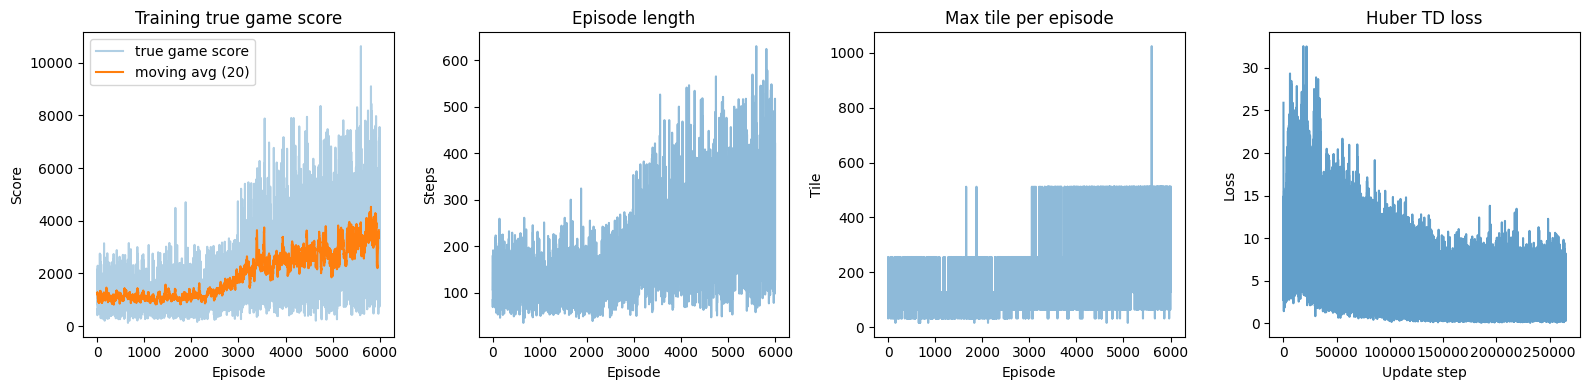

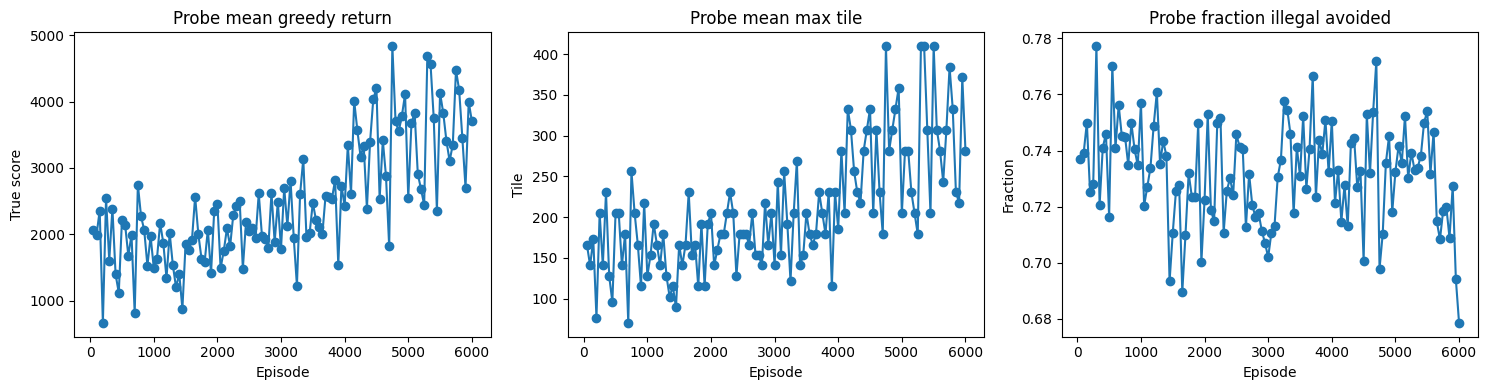

In [14]:
def moving_average(x, w=20):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w, dtype=np.float32) / w, mode="valid")


plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.plot(run["episode_true_scores"], alpha=0.35, label="true game score")
ma = moving_average(run["episode_true_scores"], 20)
plt.plot(range(len(ma)), ma, label="moving avg (20)")
plt.title("Training true game score")
plt.xlabel("Episode")
plt.ylabel("Score")
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(run["episode_lengths"], alpha=0.5)
plt.title("Episode length")
plt.xlabel("Episode")
plt.ylabel("Steps")

plt.subplot(1, 4, 3)
plt.plot(run["episode_max_tiles"], alpha=0.5)
plt.title("Max tile per episode")
plt.xlabel("Episode")
plt.ylabel("Tile")

plt.subplot(1, 4, 4)
plt.plot(run["loss_history"], alpha=0.7)
plt.title("Huber TD loss")
plt.xlabel("Update step")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

if not run["probe_df"].empty:
    probe_df = run["probe_df"]
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(probe_df["episode"], probe_df["mean_greedy_return"], marker="o")
    plt.title("Probe mean greedy return")
    plt.xlabel("Episode")
    plt.ylabel("True score")

    plt.subplot(1, 3, 2)
    plt.plot(probe_df["episode"], probe_df["mean_max_tile"], marker="o")
    plt.title("Probe mean max tile")
    plt.xlabel("Episode")
    plt.ylabel("Tile")

    plt.subplot(1, 3, 3)
    plt.plot(probe_df["episode"], probe_df["fraction_illegal_actions_avoided"], marker="o")
    plt.title("Probe fraction illegal avoided")
    plt.xlabel("Episode")
    plt.ylabel("Fraction")

    plt.tight_layout()
    plt.show()

## 8. Đánh giá cuối trên nhiều seed

Đây là một trong những phần quan trọng nhất của toàn bộ notebook, vì nó quyết định cách chúng ta kết luận về chất lượng mô hình. Thay vì chỉ chạy một rollout duy nhất rồi lấy kết quả đó làm đại diện, notebook thực hiện **multi-seed evaluation** và in ra kết quả theo từng seed trước khi tổng hợp thống kê chung.

Cách làm này giúp đánh giá trở nên trung thực hơn. Với một game ngẫu nhiên như 2048, một seed đẹp có thể làm người dùng tưởng mô hình mạnh hơn thực tế, trong khi một seed xấu có thể làm ta đánh giá thấp mô hình. Bởi vậy, việc xem score từng seed, max tile từng seed, số bước thực thi và reward train tích luỹ cho từng ván sẽ giúp bức tranh rõ ràng hơn. Sau đó notebook mới tính các thống kê tổng hợp như mean, standard deviation, median, mean max tile, phân bố max tile và fraction of illegal actions avoided.

Một nguyên tắc được duy trì xuyên suốt là: **dù train bằng reward shaping, evaluation cuối vẫn báo true game score**. Điều này giúp kết quả có thể so sánh được giữa các cấu hình khác nhau và có ý nghĩa hơn khi đưa vào báo cáo.

In [15]:
final_eval = run["final_eval"]

print("Per-seed evaluation results:")
for row in final_eval["per_seed_results"].itertuples(index=False):
    print(
        f"  seed={row.seed} | score={row.greedy_return:.2f} | "
        f"max_tile={row.max_tile} | steps={row.steps} | train_reward={row.train_reward_sum:.2f}"
    )

print("\nAggregate metrics:")
print("Mean greedy return:", final_eval["mean_greedy_return"])
print("Std greedy return:", final_eval["std_greedy_return"])
print("Median greedy return:", final_eval["median_greedy_return"])
print("Mean training reward:", final_eval["mean_train_reward"])
print("Mean max tile:", final_eval["mean_max_tile"])
print("Max tile distribution:", final_eval["max_tile_distribution"])
print("Fraction of illegal actions avoided:", final_eval["fraction_illegal_actions_avoided"])
print("Number of eval seeds:", final_eval["num_eval_seeds"])

display(final_eval["table"].head(15))

Per-seed evaluation results:
  seed=2001 | score=5824.00 | max_tile=512 | steps=423 | train_reward=4448.27
  seed=2002 | score=2992.00 | max_tile=256 | steps=247 | train_reward=2548.38
  seed=2003 | score=3000.00 | max_tile=256 | steps=253 | train_reward=2537.99
  seed=2004 | score=4044.00 | max_tile=256 | steps=333 | train_reward=3406.70
  seed=2005 | score=1752.00 | max_tile=128 | steps=178 | train_reward=1780.36
  seed=2006 | score=2232.00 | max_tile=256 | steps=188 | train_reward=1943.02
  seed=2007 | score=2856.00 | max_tile=256 | steps=244 | train_reward=2473.58
  seed=2008 | score=772.00 | max_tile=64 | steps=98 | train_reward=910.95
  seed=2009 | score=3948.00 | max_tile=256 | steps=327 | train_reward=3340.45
  seed=2010 | score=2984.00 | max_tile=256 | steps=243 | train_reward=2446.24
  seed=2011 | score=688.00 | max_tile=64 | steps=90 | train_reward=783.55
  seed=2012 | score=2796.00 | max_tile=256 | steps=239 | train_reward=2496.80
  seed=2013 | score=4552.00 | max_tile=256 

,seed,greedy_return,train_reward_sum,steps,max_tile
0,2041,7796.0,5603.983274,537,512
1,2027,6844.0,4943.397070,472,512
2,2014,6792.0,4870.809098,458,512
3,2022,6384.0,4768.058896,456,512
4,2040,5960.0,4371.656565,425,512
5,2049,5900.0,4343.591812,414,512
6,2001,5824.0,4448.274731,423,512
7,2032,5708.0,4179.063605,404,512
8,2020,4736.0,3426.496480,328,512
9,2013,4552.0,3641.271112,346,256


In [16]:
# A compact summary table for reporting
report_df = pd.DataFrame([{
    "train_seed": run["train_seed"],
    "reward_mode": run["config"]["REWARD_MODE"],
    "n_step": run["config"]["N_STEP"],
    "use_prioritized_replay": run["config"]["USE_PRIORITIZED_REPLAY"],
    "num_eval_seeds": final_eval["num_eval_seeds"],
    "mean_greedy_return": final_eval["mean_greedy_return"],
    "std_greedy_return": final_eval["std_greedy_return"],
    "median_greedy_return": final_eval["median_greedy_return"],
    "mean_train_reward": final_eval["mean_train_reward"],
    "mean_max_tile": final_eval["mean_max_tile"],
    "fraction_illegal_actions_avoided": final_eval["fraction_illegal_actions_avoided"],
}])
report_df

,train_seed,reward_mode,n_step,use_prioritized_replay,num_eval_seeds,mean_greedy_return,std_greedy_return,median_greedy_return,mean_train_reward,mean_max_tile,fraction_illegal_actions_avoided
0,7,strategic_shaped,3,True,50,3450.24,1601.452173,3072.0,2858.021376,271.36,0.709166


## 9. Kiểm tra chi tiết một greedy rollout

Cell này in ra độ dài rollout, bàn cờ cuối cùng và một số bước cuối của ván chơi để người đọc có thể quan sát trực tiếp cấu trúc bàn cờ, hành động được chọn và mối quan hệ giữa raw argmax với legal action mask.

Phân tích một rollout không đủ để kết luận mô hình mạnh hay yếu, nhưng nó lại rất hữu ích về mặt định tính. Chẳng hạn, ta có thể kiểm tra xem agent có xu hướng giữ max tile ở góc không, có phá cấu trúc đã xây dựng không, hay có thường xuyên muốn chọn các hành động bất hợp lệ rồi mới bị mask sửa lại hay không. Đây là lớp thông tin mà các thống kê trung bình khó thể hiện đầy đủ.

In [17]:

rollout = run["rollout_trace"] or []
print("Rollout length:", len(rollout))
if rollout:
    print("Final board:")
    print(rollout[-1]["board"])

n_show = min(5, len(rollout))
for i, step_info in enumerate(rollout[-n_show:], start=max(1, len(rollout) - n_show + 1)):
    print("=" * 70)
    print(
        f"Step {i} | action={step_info['action']} | raw_argmax={step_info['raw_argmax']} | "
        f"raw_argmax_is_legal={step_info['raw_argmax_is_legal']} | reward={step_info['reward']:.2f}"
    )
    print(step_info["board"])


Rollout length: 262
Final board:
[[  2   8   4   2]
 [  4  16   8   4]
 [ 16  32  16   8]
 [256   2 128  64]]
Step 258 | action=2 | raw_argmax=2 | raw_argmax_is_legal=True | reward=16.85
[[  2   4   2   2]
 [  2  16   8   4]
 [ 16  32  16   8]
 [256   2 128  64]]
Step 259 | action=2 | raw_argmax=2 | raw_argmax_is_legal=True | reward=9.79
[[  2   4   2   2]
 [  4  16   8   4]
 [ 16  32  16   8]
 [256   2 128  64]]
Step 260 | action=3 | raw_argmax=2 | raw_argmax_is_legal=False | reward=9.79
[[  2   4   4   2]
 [  4  16   8   4]
 [ 16  32  16   8]
 [256   2 128  64]]
Step 261 | action=3 | raw_argmax=2 | raw_argmax_is_legal=False | reward=13.17
[[  2   8   2   2]
 [  4  16   8   4]
 [ 16  32  16   8]
 [256   2 128  64]]
Step 262 | action=3 | raw_argmax=2 | raw_argmax_is_legal=False | reward=9.79
[[  2   8   4   2]
 [  4  16   8   4]
 [ 16  32  16   8]
 [256   2 128  64]]


## 10. Một vài ablation nhóm đề xuất

Nếu muốn tách xem từng thành phần đóng góp bao nhiêu, có thể thử thêm vài ablation đơn giản như:
1. quay về reward thuần `delta_return`;
2. dùng `state_rewards`;
3. dùng reward shaping cơ bản;
4. tắt dueling head;
5. thay đổi tốc độ decay của epsilon, learning rate hoặc số episode train.

In [18]:

# Example ablation configs (disabled by default because training is expensive)
ABLATIONS = [
    {"name": "delta_return_baseline", "REWARD_MODE": "delta_return", "USE_DUELING": True},
    {"name": "state_rewards", "REWARD_MODE": "state_rewards", "USE_DUELING": True},
    {"name": "shaped_reward", "REWARD_MODE": "shaped", "USE_DUELING": True},
    {"name": "no_dueling", "REWARD_MODE": "delta_return", "USE_DUELING": False},
]

# To run ablations, uncomment below.
# ablation_rows = []
# for variant in ABLATIONS:
#     cfg = copy.deepcopy(CONFIG)
#     cfg.update({k: v for k, v in variant.items() if k != "name"})
#     result = train_one_seed(cfg, train_seed=cfg["TRAIN_SEED"])
#     ablation_rows.append({
#         "name": variant["name"],
#         "mean_greedy_return": result["final_eval"]["mean_greedy_return"],
#         "mean_max_tile": result["final_eval"]["mean_max_tile"],
#         "fraction_illegal_actions_avoided": result["final_eval"]["fraction_illegal_actions_avoided"],
#     })
# pd.DataFrame(ablation_rows).sort_values("mean_greedy_return", ascending=False)


## 11. Lưu checkpoint

Khác với checkpoint định kỳ phục vụ train/resume ở phía trên, đây là file mô hình được xuất ra ở cuối notebook.

In [19]:

checkpoint = {
    "model_state_dict": run["q_net"].state_dict(),
    "target_state_dict": run["target_net"].state_dict(),
    "config": run["config"],
    "in_channels": run["in_channels"],
    "num_actions": run["num_actions"],
    "episode_returns": run["episode_returns"],
    "episode_true_scores": run["episode_true_scores"],
    "episode_lengths": run["episode_lengths"],
    "episode_max_tiles": run["episode_max_tiles"],
    "loss_history": run["loss_history"],
    "final_eval": {
        k: v for k, v in run["final_eval"].items() if k not in {"table", "per_seed_results"}
    },
    "latest_checkpoint_path": run.get("latest_checkpoint_path"),
}

torch.save(checkpoint, CONFIG["SAVE_PATH"])
print("Saved final model checkpoint to:", CONFIG["SAVE_PATH"])
print("Latest resumable training checkpoint:", run.get("latest_checkpoint_path"))


Saved final model checkpoint to: dqn_2048_v4_best_probe.pt
Latest resumable training checkpoint: ckpt_2048_v4_plateau_fix/seed_7_latest.pt


## 12. Tóm tắt những gì notebook phiên bản cải tiến cho 2048 đã triển khai

Phiên bản này là kết quả của quá trình cải tiến có mục tiêu. Trong notebook hiện tại, mô hình đã được trang bị đầy đủ các thành phần sau:
- wrapper quan sát giàu đặc trưng hơn cho bàn cờ 2048;
- Q-network tích chập với dueling heads;
- Double DQN để giảm overestimation;
- Huber loss để ổn định huấn luyện;
- reward shaping mạnh hơn, bám sát các heuristics quan trọng của 2048;
- n-step returns;
- prioritized replay;
- đánh giá cuối trên nhiều seed;
- in kết quả theo từng seed trước khi tính thống kê tổng;
- đo tỷ lệ hành động bất hợp lệ theo raw argmax trước masking;
- exploration giảm chậm hơn;
- replay buffer lớn hơn;
- probe evaluation định kỳ;
- lưu checkpoint tốt nhất theo probe;
- tuỳ chọn dùng checkpoint tốt nhất này cho đánh giá cuối.